# **Day 4 — Assignment**
**Exploratory Data Analysis & Combining DataFrames — winequality-red.csv**

**Section 1 — EDA Practice (mirrors 06_Pandas_practice_and_EDA)**

**Task 1:** Read winequality-red.csv, then clean the column names: make every name
lowercase and replace any spaces with underscores.

In [114]:
# importing the modules

import pandas as pd
import matplotlib.pyplot as plt

In [115]:
# load red wine data

red_wine_df = pd.read_csv('../data/winequality-red.csv', delimiter=';')

In [116]:
red_wine_df.shape

(1599, 12)

In [117]:
red_wine_df.columns              

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='str')

-> Column names already lowercase

In [118]:
cols = red_wine_df.columns
cols = [c.replace(' ', '_') for c in cols]              # substituting spaces with underscore
red_wine_df.columns = cols
red_wine_df.columns

Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='str')

**Task 2:** Get the frequency of each quality score with value_counts(), then plot it as a pie
chart.

In [119]:
red_wine_df.quality.unique()                # quality values in the dataset

array([5, 6, 7, 4, 8, 3])

In [120]:
red_wine_df['quality'].value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

Text(0.5, 1.0, 'Share of quality scores')

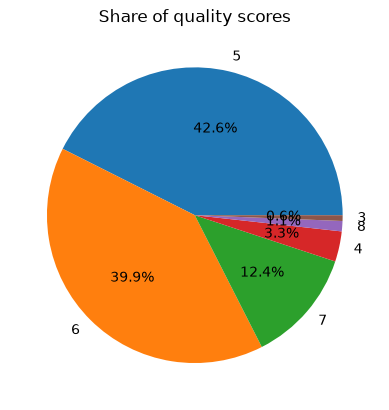

In [121]:
red_wine_df['quality'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title("Share of quality scores")

**Task 3:** Plot that same frequency as a bar chart instead.

Text(0.5, 1.0, 'Frequency of quality scores')

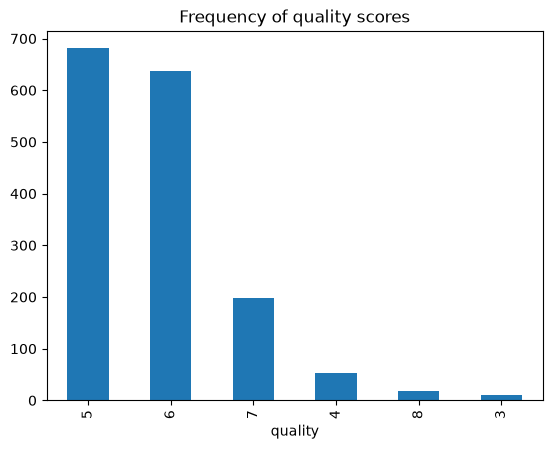

In [122]:
red_wine_df['quality'].value_counts().plot(kind='bar')

plt.title("Frequency of quality scores")

<Axes: xlabel='quality'>

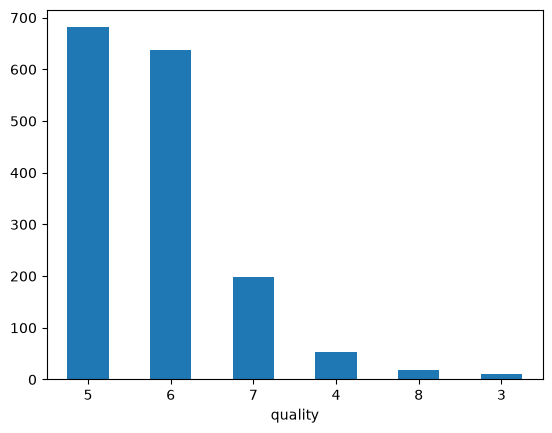

In [123]:
red_wine_df['quality'].value_counts().plot(kind='bar', rot=0)           # removing rotation of x-axis values (from ChatGPT)



**Task 4:** Create a new column called high_alcohol that's True wherever a wine's alcohol
is above the column's own mean. Build a crosstab of quality against high_alcohol,
including margins (row/column subtotals).

In [124]:
red_wine_df["alcohol"].mean()

np.float64(10.422983114446529)

In [125]:
# for wines > 10.42 % alcohol:
red_wine_df["high_alcohol"] = red_wine_df["alcohol"] > red_wine_df["alcohol"].mean()
red_wine_df


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,high_alcohol
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,False
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,False
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,False
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,False
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,True
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,True
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,True
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,False


In [126]:
pd.crosstab(red_wine_df["quality"], red_wine_df["high_alcohol"], margins=True)

high_alcohol,False,True,All
quality,,,
3,7,3,10
4,33,20,53
5,544,137,681
6,303,335,638
7,27,172,199
8,2,16,18
All,916,683,1599


**Task 5:** Investigate the residual_sugar column: find its minimum, maximum, and how
many rows have a value above 8. Look at the 5 highest values along with their quality
scores — do the sweetest wines tend to score especially high or low?

In [127]:
red_wine_df

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,high_alcohol
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,False
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,False
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,False
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,False
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,True
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,True
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,True
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,False


In [128]:
print(red_wine_df['residual_sugar'].min())                  # minimum
print(red_wine_df['residual_sugar'].max())                  # maximum
print((red_wine_df['residual_sugar'] > 8).sum())            # value above 8


0.9
15.5
21


In [131]:
# selecting columns, sort descending by residual sugar, top 5 values

red_wine_df[['residual_sugar', 'quality']].sort_values(by='residual_sugar', ascending=False).head()


,residual_sugar,quality
480,15.5,5
1435,15.4,6
1434,15.4,6
1574,13.9,6
1476,13.8,5


The sweetest wines tend to be mediocre.


**Task 6:** Plot a histogram of the full residual_sugar column. Then plot a second
histogram using only rows where residual_sugar is 4 or below. Which one actually
shows you something useful, and why?


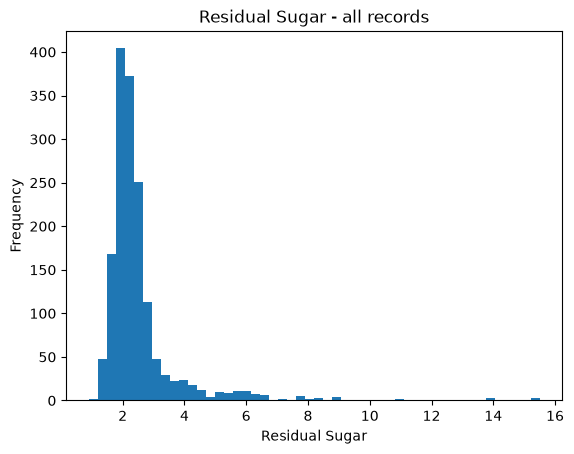

In [132]:
red_wine_df['residual_sugar'].plot(kind='hist', bins=50)
plt.title("Residual Sugar - all records")
plt.xlabel("Residual Sugar")
plt.ylabel("Frequency")
plt.show()

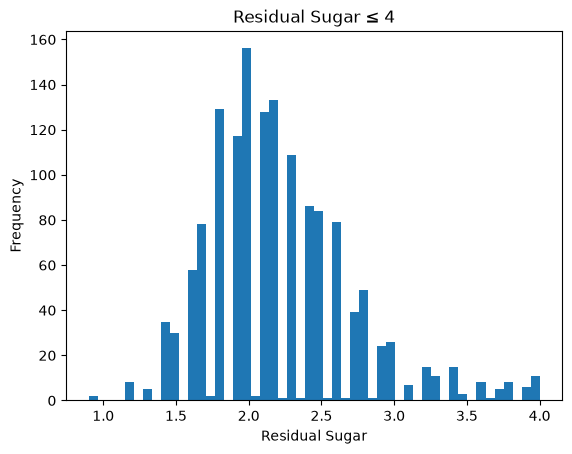

In [133]:
plt.hist(red_wine_df[red_wine_df['residual_sugar'] <= 4]['residual_sugar'],bins=50)     # masking the data frame
plt.title("Residual Sugar ≤ 4")
plt.xlabel("Residual Sugar")
plt.ylabel("Frequency")
plt.show()

Since most wines have lower sugar than 4, the second graph is more useful. The distribution of the values can be seen better, since no outliers distort the axis

**Section 2 — Combining DataFrames (mirrors 07_Combining_DataFrames)**

**Task 7:** Use pd.get_dummies() on the quality column (prefix the new columns with 'q'),
and look at the first 3 rows of the result.


In [134]:
quality_dummies = pd.get_dummies(red_wine_df.quality, prefix='q', dtype="int")
quality_dummies.head(3)

,q_3,q_4,q_5,q_6,q_7,q_8
0,0,0,1,0,0,0
1,0,0,1,0,0,0
2,0,0,1,0,0,0


**Task 8:** Use .join() to attach those dummy columns back onto the original red wine
DataFrame. Confirm the new shape and column list.

In [135]:
joined_df = red_wine_df.join(quality_dummies)
joined_df.head() 

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,high_alcohol,q_3,q_4,q_5,q_6,q_7,q_8
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,False,0,0,1,0,0,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,False,0,0,1,0,0,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,False,0,0,1,0,0,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,False,0,0,0,1,0,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,False,0,0,1,0,0,0


In [136]:
joined_df.shape

(1599, 19)

In [137]:
joined_df.columns

Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'high_alcohol', 'q_3', 'q_4',
       'q_5', 'q_6', 'q_7', 'q_8'],
      dtype='str')

1599 Rows as above, 13 + 6 new (quality) columns

**Task 9:** Build two small summary tables: the average citric acid by quality score, once
for red wine and once for white wine (winequality-white.csv), using groupby() and
reset_index().


In [138]:
# load white  wine data

white_wine_df = pd.read_csv('../data/winequality-white.csv', delimiter=';')
white_wine_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


In [139]:
# substituting spaces with underscore

cols = white_wine_df.columns
cols = [c.replace(' ', '_') for c in cols]              
white_wine_df.columns = cols
white_wine_df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [140]:
# red wine citric acid by quality

red_wine_quality_df = red_wine_df.groupby('quality').mean()['citric_acid'].reset_index()
red_wine_quality_df.head()

,quality,citric_acid
0,3,0.171000
1,4,0.174151
2,5,0.243686
3,6,0.273824
4,7,0.375176


In [141]:
# white wine citric acid by quality

white_wine_quality_df = white_wine_df.groupby('quality').mean()['citric_acid'].reset_index()
white_wine_quality_df.head()

,quality,citric_acid
0,3,0.336000
1,4,0.304233
2,5,0.337653
3,6,0.338025
4,7,0.325625


**Task 10:** Merge those two summary tables together on quality, using suffixes so you
can tell the red and white columns apart.


In [142]:
pd.merge(red_wine_quality_df, white_wine_quality_df, on=['quality'], suffixes=['_red', '_white'])

,quality,citric_acid_red,citric_acid_white
0,3,0.171000,0.336000
1,4,0.174151,0.304233
2,5,0.243686,0.337653
3,6,0.273824,0.338025
4,7,0.375176,0.325625
5,8,0.391111,0.326514


**Task 11:** Build two small DataFrames from scratch: one with columns product_id and
name for products p1 through p4; another with columns product_id and sales for
products p1 through p6 (so p5 and p6 don't exist in the first table). Merge them once
with the default join, and once with how='outer'. What's different between the two
results, and why?

In [143]:
# creating DataFrame 1 - Products

df_products = pd.DataFrame({'product_id': ['p1', 'p2', 'p3', 'p4'],'name': ['Product 1', 'Product 2', 'Product 3', 'Product 4']})
df_products

,product_id,name
0,p1,Product 1
1,p2,Product 2
2,p3,Product 3
3,p4,Product 4


In [144]:
# creating DataFrame 2 - Sales

df_sales = pd.DataFrame({'product_id': ['p1', 'p2', 'p3', 'p4', 'p5', 'p6'],
                         'sales': ['Sales 1', 'Sales 2', 'Sales 3', 'Sales 4', 'Sales 5', 'Sales 6']})
df_sales


,product_id,sales
0,p1,Sales 1
1,p2,Sales 2
2,p3,Sales 3
3,p4,Sales 4
4,p5,Sales 5
5,p6,Sales 6


In [145]:
# default join -> inner join

join_default = df_products.merge(df_sales, on='product_id')
join_default

,product_id,name,sales
0,p1,Product 1,Sales 1
1,p2,Product 2,Sales 2
2,p3,Product 3,Sales 3
3,p4,Product 4,Sales 4


In [146]:
outer_join = df_products.merge(df_sales, how='outer')
outer_join


,product_id,name,sales
0,p1,Product 1,Sales 1
1,p2,Product 2,Sales 2
2,p3,Product 3,Sales 3
3,p4,Product 4,Sales 4
4,p5,NaN,Sales 5
5,p6,NaN,Sales 6


The default join creates an intersection of the keys (product ids) -> no p5 and p6 in the first table, so neither in the merged table.

The outer join unions the keys of both tables, but since there are no product names for p5 and p6 in the products table, it returns NaN